# Sprint 1 — Section 2 REPLACEMENT: Cityscapes Dataset (Kaggle version)

## Before running this notebook:
1. Open your Kaggle notebook
2. On the right sidebar click **'+ Add Data'**
3. Search for **'Cityscapes'**
4. Add the dataset by **'pratikbarua'** (titled 'Cityscapes Image Pairs')
   - This contains leftImg8bit (frames) + gtFine (annotations) already paired
5. The data will be mounted at `/kaggle/input/cityscapes/`

---

### Also change Section 0 imports — replace the `files` upload line:
```python
# DELETE this line from Section 0:
# from google.colab import files

# Kaggle doesn't need it — files are already mounted
```

### And change Section 1 (Ghana data upload) to:
```python
# If your Ghana frames/masks are in a Kaggle dataset, add that dataset too
# and point to its path. Otherwise upload via the Kaggle notebook file sidebar.
GHANA_FRAMES_DIR = '/kaggle/input/your-ghana-dataset/frames'   # edit this
GHANA_MASKS_DIR  = '/kaggle/input/your-ghana-dataset/masks'    # edit this
```

In [2]:
!pip install segmentation-models-pytorch albumentations --quiet

import os, random, zipfile, json, csv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
Using device: cuda


## SECTION 1: Upload Your Ghanaian Data

You need two folders:
- `ghana_frames/` — the original video frames (JPG/PNG images)
- `ghana_masks/` — the corresponding binary masks (black=non-road, white=road)

**Each frame must have a matching mask with the SAME filename.**
e.g. `frame_001.jpg` pairs with `frame_001.png`

Upload your zip file containing frames and masks using the cell below.

In [3]:
# ---- EDIT THESE PATHS to match your folder structure after extraction ----
GHANA_FRAMES_DIR = '/kaggle/input/datasets/nicolenankabruce/ghana-data/frames/frames'   # folder with your original video frames
GHANA_MASKS_DIR  = '/kaggle/input/datasets/nicolenankabruce/ghana-data/road_masks/road_masks'    # folder with your binary masks

# Verify pairing
frame_files = sorted(Path(GHANA_FRAMES_DIR).glob('*'))
mask_files  = sorted(Path(GHANA_MASKS_DIR).glob('*'))
print(f'Found {len(frame_files)} frames and {len(mask_files)} masks')
print('First frame:', frame_files[0].name)
print('First mask: ', mask_files[0].name)

Found 381 frames and 381 masks
First frame: video1_frame000000.png
First mask:  video1_frame000000.png


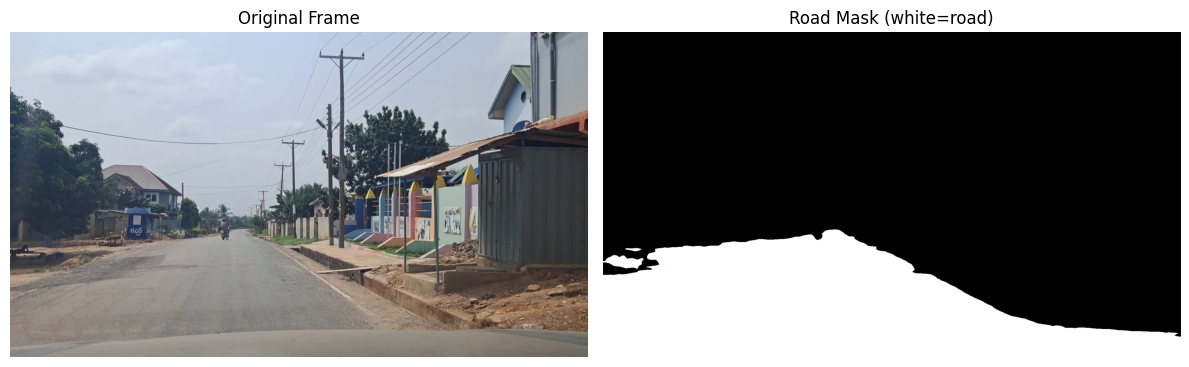

If the white region in the mask matches the road in the frame — you are good to go!


In [4]:
# Visualise one frame + its mask to confirm pairing is correct
idx = 0
frame = Image.open(frame_files[idx]).convert('RGB')
mask  = Image.open(mask_files[idx]).convert('L')  # grayscale

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(frame); axes[0].set_title('Original Frame'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Road Mask (white=road)'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('sample_pair.png', dpi=100)
plt.show()
print('If the white region in the mask matches the road in the frame — you are good to go!')

## SECTION 2 (REPLACEMENT): Load Cityscapes as Clean Domain Dataset

Cityscapes has 19 classes. We convert to binary: road (class 7) vs everything else.
The road class in Cityscapes is very clean and well-labelled — perfect for training.

In [5]:
import os
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm



In [6]:
# ── CELL 1: Locate folders ─────────────────────────────────────────────────
CS_ROOT   = Path('/kaggle/input/datasets/shuvoalok/cityscapes')

IMG_ROOT  = CS_ROOT / 'train' / 'img'
MASK_ROOT = CS_ROOT / 'train' / 'label'

cityscapes_imgs  = sorted(IMG_ROOT.glob('*.png'))
cityscapes_masks = sorted(MASK_ROOT.glob('*.png'))

print(f'Found {len(cityscapes_imgs)} images, {len(cityscapes_masks)} masks')
# Filenames should match: train1.png <-> train1.png
print('Sample image:', cityscapes_imgs[0].name)
print('Sample mask: ', cityscapes_masks[0].name)

Found 2975 images, 2975 masks
Sample image: train1.png
Sample mask:  train1.png


In [7]:
# ── DIAGNOSTIC: find what colour the road actually is ─────────────────────
# Look at the bottom-centre of the image — that's almost always road
sample_mask = np.array(Image.open(cityscapes_masks[0]).convert('RGB'))

H, W = sample_mask.shape[:2]

# Sample a small patch from the bottom-centre (very likely to be road)
patch = sample_mask[int(H*0.85):int(H*0.95), int(W*0.4):int(W*0.6)]

# Find unique colours in that patch and how often they appear
pixels = patch.reshape(-1, 3)
unique, counts = np.unique(pixels, axis=0, return_counts=True)
top5 = sorted(zip(counts, unique.tolist()), reverse=True)[:5]

print('Most common colours in bottom-centre patch (most frequent = road):')
for count, colour in top5:
    print(f'  RGB{tuple(colour)} — {count} pixels')

Most common colours in bottom-centre patch (most frequent = road):
  RGB(127, 63, 128) — 510 pixels


In [8]:
# ── CELL 2: Convert colour masks to binary road masks ──────────────────────
#
# In this dataset's colour-coded masks:
#   Road = RGB (128, 64, 128)  <-- this is the pink/magenta you see
#   We find all pixels matching this colour and make them white (255)
#   Everything else becomes black (0)

ROAD_COLOUR = np.array([127, 63, 128], dtype=np.uint8)

os.makedirs('cityscapes_binary_masks', exist_ok=True)
valid_pairs = []

for img_path, mask_path in tqdm(zip(cityscapes_imgs, cityscapes_masks),
                                 total=len(cityscapes_imgs),
                                 desc='Converting masks'):
    mask_rgb    = np.array(Image.open(mask_path).convert('RGB'))
    # True wherever pixel matches road colour exactly
    road_pixels = np.all(mask_rgb == ROAD_COLOUR, axis=-1)
    binary      = (road_pixels).astype(np.uint8) * 255

    out_path = Path('cityscapes_binary_masks') / mask_path.name
    Image.fromarray(binary).save(out_path)
    valid_pairs.append((img_path, out_path))

print(f'Converted {len(valid_pairs)} pairs')

Converting masks: 100%|██████████| 2975/2975 [00:29<00:00, 100.68it/s]


Converted 2975 pairs


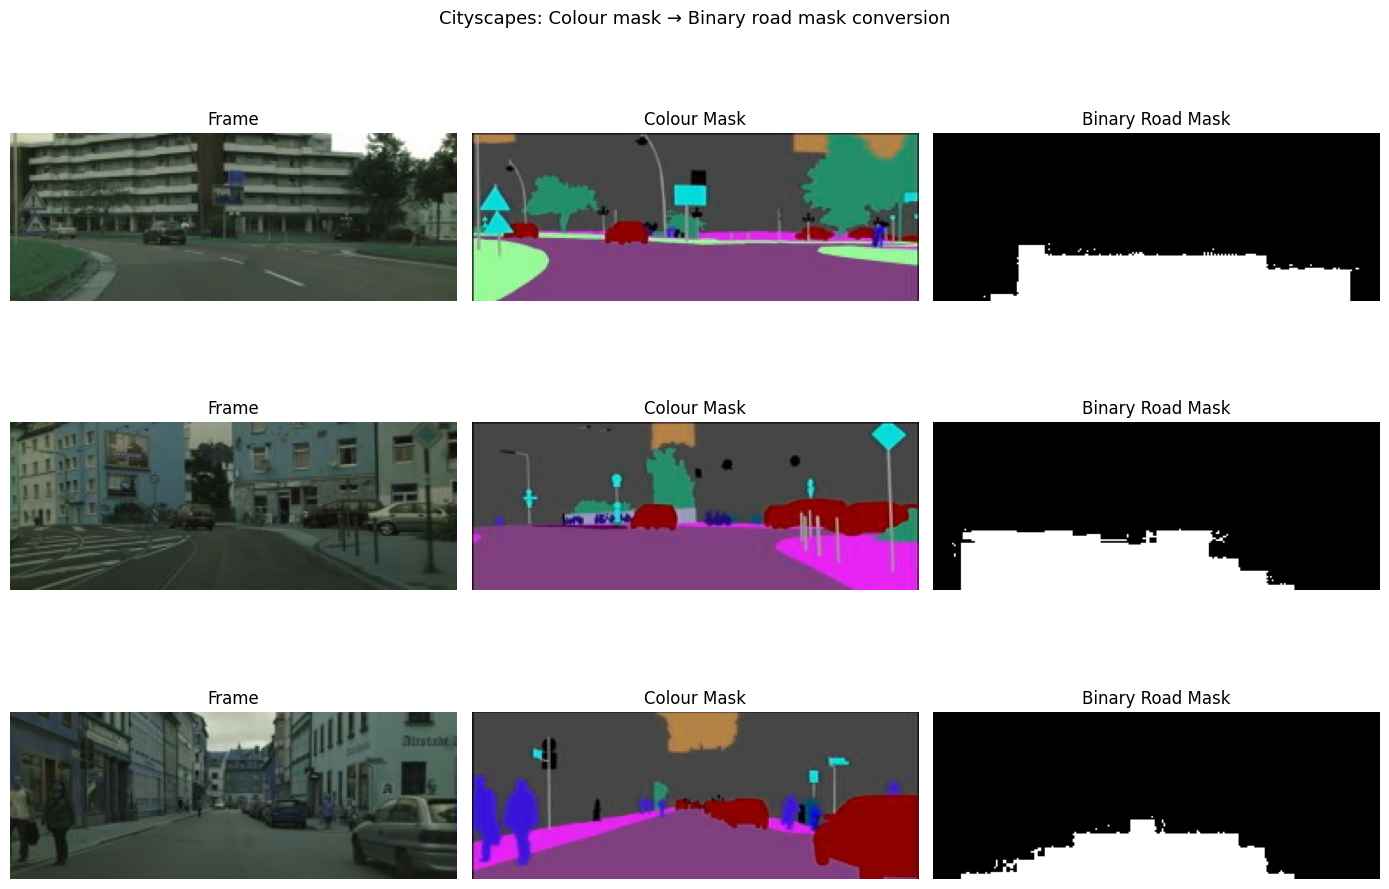

Middle column = original coloured mask, Right = what we feed to training


In [9]:
# ── CELL 3: Verify ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for i, (img_path, mask_path) in enumerate(valid_pairs[:3]):
    frame      = Image.open(img_path).convert('RGB')
    orig_mask  = Image.open(  # show original colour mask too
        MASK_ROOT / mask_path.name).convert('RGB')
    binary     = Image.open(mask_path).convert('L')

    axes[i,0].imshow(frame);      axes[i,0].set_title('Frame');         axes[i,0].axis('off')
    axes[i,1].imshow(orig_mask);  axes[i,1].set_title('Colour Mask');   axes[i,1].axis('off')
    axes[i,2].imshow(binary, cmap='gray'); axes[i,2].set_title('Binary Road Mask'); axes[i,2].axis('off')

plt.suptitle('Cityscapes: Colour mask → Binary road mask conversion', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/cityscapes_samples.png', dpi=100)
plt.show()
print('Middle column = original coloured mask, Right = what we feed to training')

In [10]:
# ── Cap dataset size for training speed ───────────────────────────────────
# Full Cityscapes train = 2975 images. 500 is enough for this assignment
# and will train much faster on Kaggle's free GPU.
# Increase MAX_SAMPLES if you have time / want better clean-domain performance.

MAX_SAMPLES = 500
random.shuffle(valid_pairs)
valid_pairs = valid_pairs[:MAX_SAMPLES]

split = int(0.8 * len(valid_pairs))
train_pairs = valid_pairs[:split]
val_pairs   = valid_pairs[split:]

train_imgs  = [p[0] for p in train_pairs]
train_masks = [p[1] for p in train_pairs]
val_imgs    = [p[0] for p in val_pairs]
val_masks   = [p[1] for p in val_pairs]

print(f'Train: {len(train_imgs)} | Val: {len(val_imgs)}')
print('Ready — continue from Section 3 onwards exactly as before.')

Train: 400 | Val: 100
Ready — continue from Section 3 onwards exactly as before.


## SECTION 3: Dataset & Dataloader

A PyTorch Dataset pairs each image with its mask and prepares them for training.

In [11]:
IMG_SIZE = (256, 256)  # resize everything to this for training

class RoadSegDataset(Dataset):
    """
    Loads (image, binary_mask) pairs.
    image:  RGB float tensor [3, H, W], normalised
    mask:   float tensor [1, H, W], values 0.0 or 1.0
    """
    def __init__(self, img_paths, mask_paths, augment_fn=None):
        assert len(img_paths) == len(mask_paths), 'Must have equal images and masks'
        self.img_paths   = img_paths
        self.mask_paths  = mask_paths
        self.augment_fn  = augment_fn  # albumentations pipeline or None

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.img_paths[idx]).convert('RGB').resize(IMG_SIZE))
        mask  = np.array(Image.open(self.mask_paths[idx]).convert('L').resize(IMG_SIZE))

        # Binarise: anything >128 = road (1), else non-road (0)
        mask = (mask > 128).astype(np.float32)

        if self.augment_fn:
            augmented = self.augment_fn(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']
        else:
            # Standard normalisation only
            basic = A.Compose([
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
            out   = basic(image=image, mask=mask)
            image = out['image']
            mask  = out['mask']

        # mask shape: [H, W] -> [1, H, W]
        if mask.ndim == 2:
            mask = mask.unsqueeze(0) if isinstance(mask, torch.Tensor) else mask[None]
        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).unsqueeze(0)

        return image.float(), mask.float()

In [12]:
# Build cityscapes dataset — use 80% for training, 20% for validation
cityscapes_binary_masks = sorted(Path('cityscapes_binary_masks').glob('*.png'))

split = int(0.8 * len(cityscapes_imgs))
train_imgs,  val_imgs  = list(cityscapes_imgs[:split]),         list(cityscapes_imgs[split:])
train_masks, val_masks = list(cityscapes_binary_masks[:split]), list(cityscapes_binary_masks[split:])

train_dataset = RoadSegDataset(train_imgs, train_masks)
val_dataset   = RoadSegDataset(val_imgs,   val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')

Train: 2380 | Val: 595


## SECTION 4: U-Net Architecture (built from scratch in PyTorch)

U-Net is the standard architecture for segmentation. It has:
- An **encoder** (left side): progressively shrinks the image while learning features
- A **bottleneck**: the most compressed representation
- A **decoder** (right side): upscales back to original size, adding detail from encoder via skip connections

The output is a single-channel mask (road probability per pixel).

In [13]:
class DoubleConv(nn.Module):
    """Two sequential Conv->BN->ReLU blocks — the basic U-Net building block."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Lightweight U-Net for binary road segmentation.
    Input:  [B, 3, H, W] RGB image
    Output: [B, 1, H, W] road probability map (apply sigmoid to get 0-1)
    """
    def __init__(self, features=[32, 64, 128, 256]):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        self.enc1 = DoubleConv(3,           features[0])
        self.enc2 = DoubleConv(features[0], features[1])
        self.enc3 = DoubleConv(features[1], features[2])
        self.enc4 = DoubleConv(features[2], features[3])

        # Bottleneck
        self.bottleneck = DoubleConv(features[3], features[3]*2)

        # Decoder (upconv + double conv)
        self.up4    = nn.ConvTranspose2d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.dec4   = DoubleConv(features[3]*2, features[3])

        self.up3    = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.dec3   = DoubleConv(features[2]*2, features[2])

        self.up2    = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.dec2   = DoubleConv(features[1]*2, features[1])

        self.up1    = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.dec1   = DoubleConv(features[0]*2, features[0])

        # Final 1x1 conv to produce single-channel output
        self.final  = nn.Conv2d(features[0], 1, kernel_size=1)

    def forward(self, x):
        # Encoder path
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b  = self.bottleneck(self.pool(e4))

        # Decoder path (with skip connections from encoder)
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)  # raw logits — sigmoid applied in loss


model = UNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net ready. Trainable parameters: {total_params:,}')

U-Net ready. Trainable parameters: 7,763,041


## SECTION 5: Loss Function & IoU Metric

- **BCEWithLogitsLoss**: standard binary cross-entropy. Measures how wrong each pixel prediction is.
- **IoU (Intersection over Union)**: the evaluation metric. Higher = better.
  - IoU = (pixels correctly predicted as road) / (all pixels predicted OR actually road)
  - 1.0 = perfect, 0.0 = completely wrong

In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def compute_iou(preds, targets, threshold=0.5):
    """Compute mean IoU over a batch."""
    preds   = (torch.sigmoid(preds) > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(1,2,3))
    union        = ((preds + targets) > 0).float().sum(dim=(1,2,3))
    iou = (intersection / (union + 1e-6)).mean().item()
    return iou

## SECTION 6: Training Loop — Clean Domain (Cityscapes)

In [15]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, total_iou = 0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_iou  += compute_iou(preds, masks)
    return total_loss / len(loader), total_iou / len(loader)


def evaluate(model, loader):
    model.eval()
    total_loss, total_iou = 0, 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            total_loss += criterion(preds, masks).item()
            total_iou  += compute_iou(preds, masks)
    return total_loss / len(loader), total_iou / len(loader)


NUM_EPOCHS = 20
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}
best_iou = 0

print('Training on cityscapes (clean domain)...')
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_iou = train_one_epoch(model, train_loader)
    vl_loss, vl_iou = evaluate(model, val_loader)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_iou'].append(tr_iou)
    history['val_iou'].append(vl_iou)

    if vl_iou > best_iou:
        best_iou = vl_iou
        torch.save(model.state_dict(), 'unet_clean.pth')

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} IoU: {tr_iou:.4f} | '
          f'Val Loss: {vl_loss:.4f} IoU: {vl_iou:.4f}')

print(f'\nBest val IoU on cityscapes: {best_iou:.4f}')

Training on cityscapes (clean domain)...
Epoch 01/20 | Train Loss: 0.2085 IoU: 0.6925 | Val Loss: 0.1244 IoU: 0.7703
Epoch 02/20 | Train Loss: 0.0980 IoU: 0.7697 | Val Loss: 0.0890 IoU: 0.8022
Epoch 03/20 | Train Loss: 0.0826 IoU: 0.7956 | Val Loss: 0.0819 IoU: 0.8158
Epoch 04/20 | Train Loss: 0.0750 IoU: 0.8127 | Val Loss: 0.0828 IoU: 0.8159
Epoch 05/20 | Train Loss: 0.0703 IoU: 0.8223 | Val Loss: 0.0836 IoU: 0.8253
Epoch 06/20 | Train Loss: 0.0681 IoU: 0.8283 | Val Loss: 0.0771 IoU: 0.8259
Epoch 07/20 | Train Loss: 0.0643 IoU: 0.8361 | Val Loss: 0.0803 IoU: 0.8232
Epoch 08/20 | Train Loss: 0.0606 IoU: 0.8423 | Val Loss: 0.0703 IoU: 0.8330
Epoch 09/20 | Train Loss: 0.0587 IoU: 0.8481 | Val Loss: 0.0640 IoU: 0.8449
Epoch 10/20 | Train Loss: 0.0564 IoU: 0.8511 | Val Loss: 0.0694 IoU: 0.8403
Epoch 11/20 | Train Loss: 0.0547 IoU: 0.8570 | Val Loss: 0.0659 IoU: 0.8473
Epoch 12/20 | Train Loss: 0.0513 IoU: 0.8619 | Val Loss: 0.0663 IoU: 0.8449
Epoch 13/20 | Train Loss: 0.0508 IoU: 0.8628 | 

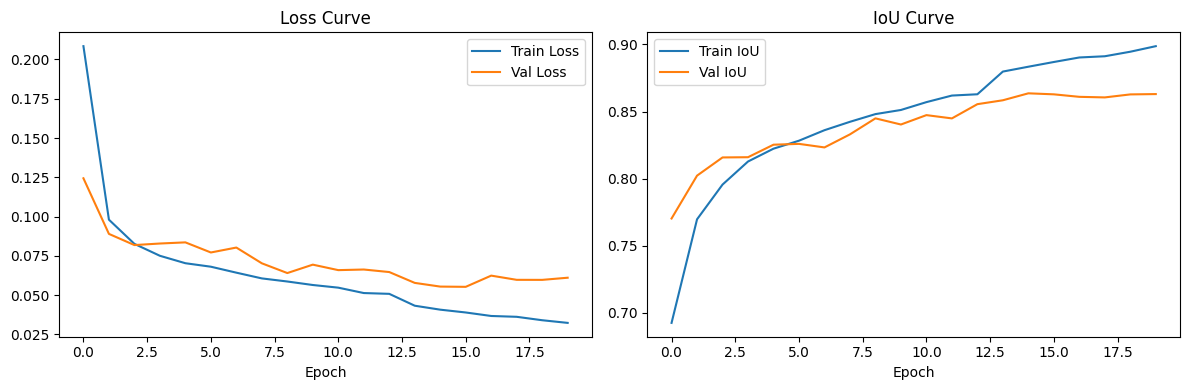

In [16]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_iou'], label='Train IoU')
axes[1].plot(history['val_iou'],   label='Val IoU')
axes[1].set_title('IoU Curve'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()

## SECTION 7: Test on Ghanaian Footage (Domain Shift)

This is the key moment. We take the model trained on clean UK data
and test it on YOUR Ghanaian footage. We expect it to perform worse.
That performance gap IS the domain shift problem the assignment is about.

In [17]:
# Load best checkpoint
model.load_state_dict(torch.load('unet_clean.pth', map_location=DEVICE))
model.eval()

# Build Ghana dataset (no augmentations — we want to see raw performance)
ghana_dataset = RoadSegDataset(
    list(Path(GHANA_FRAMES_DIR).glob('*')),
    list(Path(GHANA_MASKS_DIR).glob('*'))
)
ghana_loader = DataLoader(ghana_dataset, batch_size=4, shuffle=False)

cityscapes_val_iou  = evaluate(model, val_loader)[1]
ghana_iou       = evaluate(model, ghana_loader)[1]

print('='*50)
print(f'IoU on cityscapes (clean data):    {cityscapes_val_iou:.4f}')
print(f'IoU on Ghanaian footage:          {ghana_iou:.4f}')
print(f'Domain Shift Drop:                {cityscapes_val_iou - ghana_iou:.4f}')
print('='*50)
print('A significant drop confirms visual domain shift.')

IoU on cityscapes (clean data):    0.8635
IoU on Ghanaian footage:          0.6946
Domain Shift Drop:                0.1690
A significant drop confirms visual domain shift.


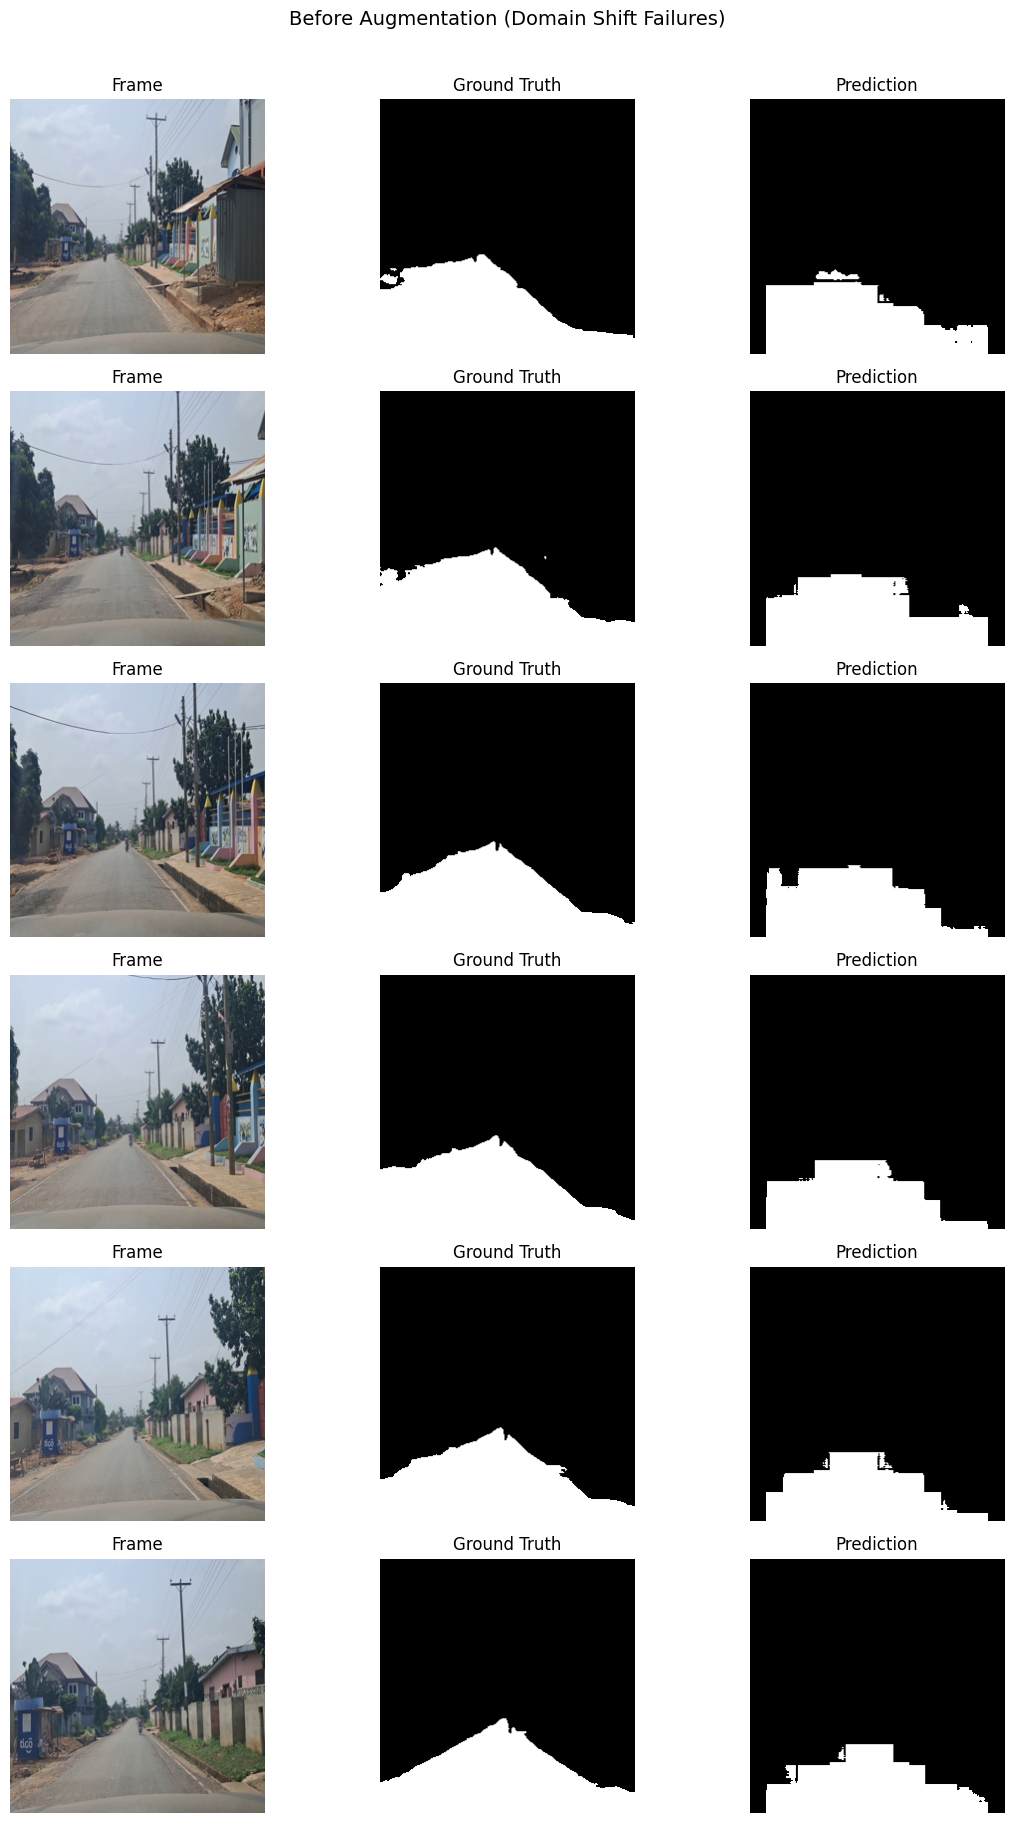

'before_augmentation_(domain_shift_failures).png'

In [18]:
# Visualise failures on Ghanaian frames
def visualise_predictions(model, img_paths, mask_paths, n=6, title='Predictions'):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(12, n*3))
    for i in range(n):
        img_np   = np.array(Image.open(img_paths[i]).convert('RGB').resize(IMG_SIZE))
        mask_np  = (np.array(Image.open(mask_paths[i]).convert('L').resize(IMG_SIZE)) > 128).astype(np.float32)

        basic = A.Compose([A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2()])
        inp   = basic(image=img_np, mask=mask_np)['image'].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = (torch.sigmoid(model(inp)) > 0.5).float().squeeze().cpu().numpy()

        axes[i,0].imshow(img_np);            axes[i,0].set_title('Frame');          axes[i,0].axis('off')
        axes[i,1].imshow(mask_np, cmap='gray'); axes[i,1].set_title('Ground Truth'); axes[i,1].axis('off')
        axes[i,2].imshow(pred,    cmap='gray'); axes[i,2].set_title('Prediction');   axes[i,2].axis('off')

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    fname = title.replace(' ', '_').lower() + '.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()
    return fname

ghana_img_paths  = sorted(Path(GHANA_FRAMES_DIR).glob('*'))
ghana_mask_paths = sorted(Path(GHANA_MASKS_DIR).glob('*'))

n_show = min(6, len(ghana_img_paths))
visualise_predictions(model, ghana_img_paths, ghana_mask_paths, n=n_show,
                      title='Before Augmentation (Domain Shift Failures)')

## Also update Section 7 — Ghana dataset loading

Replace the `files.upload()` block with:

```python
# If Ghana data is added as a Kaggle dataset:
GHANA_FRAMES_DIR = '/kaggle/input/your-dataset-name/frames'
GHANA_MASKS_DIR  = '/kaggle/input/your-dataset-name/masks'

# Verify
ghana_img_paths  = sorted(Path(GHANA_FRAMES_DIR).glob('*'))
ghana_mask_paths = sorted(Path(GHANA_MASKS_DIR).glob('*'))
print(f'Ghana: {len(ghana_img_paths)} frames, {len(ghana_mask_paths)} masks')
```

## And update the model save/load paths

Kaggle notebooks save to `/kaggle/working/` by default, so change:
```python
# Replace all instances of:
torch.save(model.state_dict(), 'unet_clean.pth')
# With:
torch.save(model.state_dict(), '/kaggle/working/unet_clean.pth')

# And similarly for unet_augmented.pth and the outputs folder
os.makedirs('/kaggle/working/submission_outputs', exist_ok=True)
```

## Everything else in the notebook stays exactly the same ✓

## SECTION 8: Ghana-Inspired Augmentations

Now we design augmentations that simulate Ghanaian road conditions:
- **Dust/haze**: reduces visibility and contrast
- **Motion blur**: from camera vibration on uneven surfaces
- **Brightness/contrast shifts**: harsh sunlight vs shadow
- **Coarse dropout**: simulates occlusion from dust patches
- **Fog**: simulates hazy atmospheric conditions

These are applied *during training* so the model learns to be robust to them.

In [19]:
ghana_augment = A.Compose([
    # Brightness/contrast — reduce limits so it never goes fully black
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.5),
    A.CLAHE(clip_limit=2.0, p=0.4),

    # Blur — camera shake, reduced intensity
    A.OneOf([
        A.MotionBlur(blur_limit=(3, 9), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.5),

    # Noise — much lower variance so image stays recognisable
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),
    A.CoarseDropout(max_holes=4, max_height=15, max_width=15, p=0.3),

    # Fog/haze — simulates dust in the air
    A.RandomFog(fog_coef_lower=0.05, fog_coef_upper=0.2, p=0.3),

    # Slight geometric shift from road vibration
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05, rotate_limit=3, p=0.3),
    A.HorizontalFlip(p=0.5),

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/tmp/ipykernel_55/3607384060.py:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),
/tmp/ipykernel_55/3607384060.py:15: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=15, max_width=15, p=0.3),
/tmp/ipykernel_55/3607384060.py:18: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.05, fog_coef_upper=0.2, p=0.3),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## SECTION 9: Retrain With Augmentations (Ablation Study)

This is the **ablation**: we compare the same model, same data,
but *with* vs *without* the Ghana augmentations.
The improvement in IoU on Ghanaian footage is your evidence that
the augmentations made the model more robust.

In [25]:
# ── Fine-tune the EXISTING good model with augmentations ──────────────────
# Load the already-trained clean model as starting point
import cv2
model_aug = UNet().to(DEVICE)
model_aug.load_state_dict(torch.load('/kaggle/working/unet_clean.pth'))

# Lower learning rate — we're fine-tuning, not training from scratch
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-4)  # 10x smaller
scheduler_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_aug, patience=2, factor=0.5)

# Milder augmentations — just enough to simulate Ghana, not destroy the image
mild_ghana_augment = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
    A.OneOf([
        A.MotionBlur(blur_limit=(3, 7), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.4),
    A.GaussNoise(var_limit=(5.0, 15.0), p=0.3),
    A.RandomFog(fog_coef_lower=0.05, fog_coef_upper=0.15, p=0.2),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

def road_specific_augment(image, mask):
    """
    Apply extra degradation specifically to road pixels,
    simulating dusty/worn asphalt that confuses the model.
    image: np.array HxWx3
    mask:  np.array HxW, values 0 or 1
    """
    result = image.copy().astype(np.float32)
    road_pixels = mask > 0.5  # True where road is

    if road_pixels.sum() > 100:  # only if road is actually visible

        # ── 1. Dusty asphalt: reduce saturation + add brownish tint ──────
        if random.random() < 0.5:
            # Desaturate road pixels (dust makes colours fade)
            road_region = result[road_pixels]
            gray = road_region.mean(axis=-1, keepdims=True)
            dust_factor = random.uniform(0.3, 0.7)
            result[road_pixels] = road_region * (1 - dust_factor) + gray * dust_factor
            # Add slight brown/yellow tint (laterite dust colour in Ghana)
            tint = np.array([180, 140, 80], dtype=np.float32)
            tint_strength = random.uniform(0.05, 0.2)
            result[road_pixels] = (result[road_pixels] * (1 - tint_strength)
                                   + tint * tint_strength)

        # ── 2. Uneven texture: add noise only to road surface ─────────────
        if random.random() < 0.5:
            noise = np.random.normal(0, random.uniform(8, 25),
                                     result[road_pixels].shape).astype(np.float32)
            result[road_pixels] = result[road_pixels] + noise

        # ── 3. Faded markings: darken patches on road randomly ────────────
        if random.random() < 0.4:
            road_coords = np.argwhere(road_pixels)
            if len(road_coords) > 0:
                for _ in range(random.randint(2, 5)):
                    centre = road_coords[random.randint(0, len(road_coords)-1)]
                    r, c   = centre
                    patch_h = random.randint(10, 40)
                    patch_w = random.randint(20, 80)
                    r1, r2 = max(0, r-patch_h//2), min(image.shape[0], r+patch_h//2)
                    c1, c2 = max(0, c-patch_w//2), min(image.shape[1], c+patch_w//2)
                    fade   = random.uniform(0.5, 0.85)
                    result[r1:r2, c1:c2] *= fade  # darken patch

    result = np.clip(result, 0, 255).astype(np.uint8)
    return result


class RoadSegDataset(Dataset):
    """Updated dataset that supports road-specific augmentation."""
    def __init__(self, img_paths, mask_paths, augment_fn=None, road_augment=False):
        self.img_paths    = img_paths
        self.mask_paths   = mask_paths
        self.augment_fn   = augment_fn
        self.road_augment = road_augment  # NEW flag

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.img_paths[idx]).convert('RGB').resize(IMG_SIZE))
        mask  = np.array(Image.open(self.mask_paths[idx]).convert('L').resize(IMG_SIZE))
        mask  = (mask > 128).astype(np.float32)

        # Apply road-specific augmentation BEFORE global augmentation
        if self.road_augment and random.random() < 0.7:
            image = road_specific_augment(image, mask)

        if self.augment_fn:
            augmented = self.augment_fn(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']
        else:
            basic = A.Compose([
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
            out  = basic(image=image, mask=mask)
            image = out['image']
            mask  = out['mask']

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).unsqueeze(0)
        elif mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image.float(), mask.float()

# train_dataset_aug = RoadSegDataset(train_imgs, train_masks,
#                                     augment_fn=mild_ghana_augment)
train_dataset_aug = RoadSegDataset(train_imgs, train_masks,
                                    augment_fn=mild_ghana_augment,
                                    road_augment=True)
train_loader_aug  = DataLoader(train_dataset_aug, batch_size=8,
                                shuffle=True, num_workers=2)

# Fewer epochs — we're just adapting, not relearning everything
FINETUNE_EPOCHS = 10
best_iou_aug = 0
history_aug  = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

print('Fine-tuning with Ghana augmentations...')
for epoch in range(1, FINETUNE_EPOCHS + 1):
    tr_loss, tr_iou = train_one_epoch(model_aug, train_loader_aug)

    model_aug.eval()
    vl_loss, vl_iou = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model_aug(imgs)
            vl_loss += criterion(preds, masks).item()
            vl_iou  += compute_iou(preds, masks)
    vl_loss /= len(val_loader)
    vl_iou  /= len(val_loader)
    scheduler_aug.step(vl_loss)

    history_aug['train_loss'].append(tr_loss)
    history_aug['val_loss'].append(vl_loss)
    history_aug['train_iou'].append(tr_iou)
    history_aug['val_iou'].append(vl_iou)

    if vl_iou > best_iou_aug:
        best_iou_aug = vl_iou
        torch.save(model_aug.state_dict(), '/kaggle/working/unet_augmented.pth')

    print(f'Epoch {epoch:02d}/{FINETUNE_EPOCHS} | '
          f'Train IoU: {tr_iou:.4f} | Val IoU: {vl_iou:.4f}')

print(f'\nBest val IoU after fine-tuning: {best_iou_aug:.4f}')

Fine-tuning with Ghana augmentations...


/tmp/ipykernel_55/1785711645.py:19: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 15.0), p=0.3),
/tmp/ipykernel_55/1785711645.py:20: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.05, fog_coef_upper=0.15, p=0.2),


Epoch 01/10 | Train IoU: 0.6238 | Val IoU: 0.8602
Epoch 02/10 | Train IoU: 0.6180 | Val IoU: 0.8598
Epoch 03/10 | Train IoU: 0.6274 | Val IoU: 0.8598
Epoch 04/10 | Train IoU: 0.6251 | Val IoU: 0.8594
Epoch 05/10 | Train IoU: 0.6273 | Val IoU: 0.8602
Epoch 06/10 | Train IoU: 0.6240 | Val IoU: 0.8591
Epoch 07/10 | Train IoU: 0.6295 | Val IoU: 0.8605
Epoch 08/10 | Train IoU: 0.6192 | Val IoU: 0.8595
Epoch 09/10 | Train IoU: 0.6231 | Val IoU: 0.8594
Epoch 10/10 | Train IoU: 0.6242 | Val IoU: 0.8602

Best val IoU after fine-tuning: 0.8605


In [26]:
# Final comparison — THE KEY RESULT FOR YOUR SUBMISSION
model.load_state_dict(torch.load('unet_clean.pth', map_location=DEVICE))
model_aug.load_state_dict(torch.load('unet_augmented.pth', map_location=DEVICE))

clean_cityscapes_iou  = evaluate(model,     val_loader)[1]
clean_ghana_iou   = evaluate(model,     ghana_loader)[1]
aug_cityscapes_iou    = evaluate(model_aug, val_loader)[1]
aug_ghana_iou     = evaluate(model_aug, ghana_loader)[1]

print('\n' + '='*60)
print('ABLATION STUDY: IoU Comparison')
print('='*60)
print(f'{"":30s} {"cityscapes (clean)":>16s} {"Ghana footage":>16s}')
print(f'{"Without augmentation":30s} {clean_cityscapes_iou:>16.4f} {clean_ghana_iou:>16.4f}')
print(f'{"With Ghana augmentations":30s} {aug_cityscapes_iou:>16.4f} {aug_ghana_iou:>16.4f}')
print(f'{"Improvement on Ghana":30s} {"":>16s} {aug_ghana_iou - clean_ghana_iou:>+16.4f}')
print('='*60)


ABLATION STUDY: IoU Comparison
                               cityscapes (clean)    Ghana footage
Without augmentation                     0.8635           0.6946
With Ghana augmentations                 0.8605           0.7267
Improvement on Ghana                                     +0.0321


## SECTION 10: Generate Submission Outputs

Save all required figures and a summary JSON for your report.

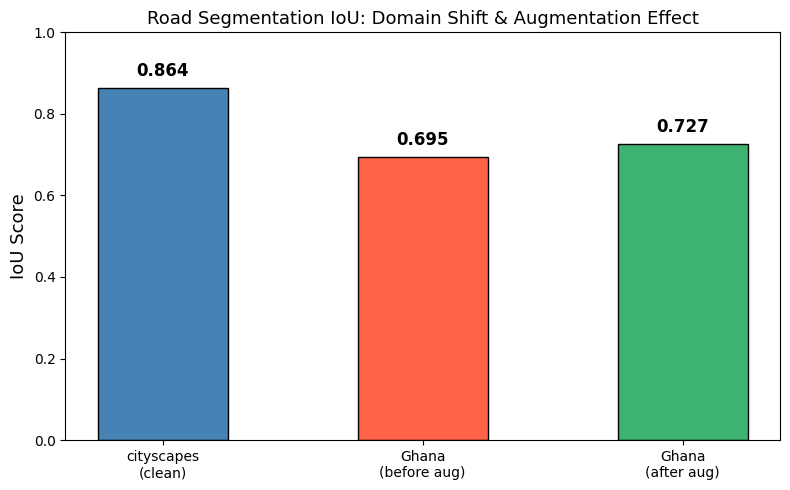

Saved to submission_outputs/
{
  "cityscapes_clean_iou": 0.8635,
  "ghana_before_augmentation_iou": 0.6946,
  "ghana_after_augmentation_iou": 0.7267,
  "domain_shift_drop": 0.169,
  "augmentation_improvement": 0.0321
}


In [27]:
os.makedirs('submission_outputs', exist_ok=True)

# Bar chart comparing IoU scores
labels   = ['cityscapes\n(clean)', 'Ghana\n(before aug)', 'Ghana\n(after aug)']
values   = [clean_cityscapes_iou, clean_ghana_iou, aug_ghana_iou]
colours  = ['steelblue', 'tomato', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colours, width=0.5, edgecolor='black')
ax.set_ylim(0, 1.0)
ax.set_ylabel('IoU Score', fontsize=13)
ax.set_title('Road Segmentation IoU: Domain Shift & Augmentation Effect', fontsize=13)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('submission_outputs/iou_comparison.png', dpi=150)
plt.show()

# Save numeric results
results = {
    'cityscapes_clean_iou':             round(clean_cityscapes_iou, 4),
    'ghana_before_augmentation_iou': round(clean_ghana_iou,  4),
    'ghana_after_augmentation_iou':  round(aug_ghana_iou,    4),
    'domain_shift_drop':            round(clean_cityscapes_iou - clean_ghana_iou, 4),
    'augmentation_improvement':     round(aug_ghana_iou - clean_ghana_iou,   4)
}
with open('submission_outputs/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Saved to submission_outputs/')
print(json.dumps(results, indent=2))

In [28]:
import os
import shutil
from IPython.display import FileLink

# 1. Create directory
os.makedirs('submission_outputs/', exist_ok=True)

# 2. Copy files (ensure these files exist first)
# shutil.copy('training_curves.png', 'submission_outputs/')
# shutil.copy('augmentation_examples.png', 'submission_outputs/')

# 3. Create the archive
shutil.make_archive('sprint1_outputs', 'zip', 'submission_outputs')

# 4. Generate a download link (Kaggle-compatible method)
FileLink('sprint1_outputs.zip')


/kaggle/working/sprint1_outputs.zip